Classification and hyperparameter tuning

In [5]:
# load COX-2 Activity dataset
import pandas as pd
df = pd.read_csv("cox2.csv")
print("Number of rows:", len(df))
df.head()




Number of rows: 462


,QikProp_.stars,QikProp_.amine,QikProp_.acid,QikProp_.rotor,QikProp_.rctvFG,QikProp_CNS,QikProp_MW,QikProp_dipole,QikProp_SASA,QikProp_FOSA,...,moe2D_vsa_acc,moe2D_vsa_don,moe2D_vsa_hyd,moe2D_vsa_other,moe2D_vsa_pol,moe2D_weinerPath,moe2D_weinerPol,moe2D_zagreb,IC50,cox2Class
0,1,0,0,1,0,0,358.882,7.645,635.022,273.363,...,32.02,0.00,268.2,6.513,0.0,1340,37,138,0.001,Inactive
1,0,0,0,2,0,-1,359.870,7.959,622.548,189.930,...,32.02,20.14,236.8,10.110,0.0,1340,37,138,0.001,Inactive
2,0,0,0,3,0,-1,355.451,7.500,610.972,268.526,...,34.52,20.14,238.4,18.560,0.0,1524,39,142,0.001,Inactive
3,1,0,0,2,0,-1,393.423,9.342,651.852,190.772,...,32.02,20.14,249.7,10.110,0.0,1898,43,156,0.001,Inactive
4,1,0,0,2,0,-1,394.315,9.409,637.688,189.933,...,32.02,20.14,255.1,10.110,0.0,1486,40,144,0.001,Inactive


The COX-2 Dataset has data on 462 different compounds that were evaluated according to their anti-COX-2 activity depending on the IC50 value (half-maximal inhibitory concentration) as active or inactive (last column). 
255 molecular descriptors (each in one column) were measured.
The goal is to predict whether a compound is a COX-2 inhibitor based on the descriptors.
COX-2-inhibitors are antiinflammatory drugs like NSAIDs

In [ ]:
# split the dataset in 75% training and 25% test set
from sklearn.model_selection import train_test_split
X = df.drop(columns=['IC50', 'cox2Class'])
y = df['cox2Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# select a learning method: random forest, doesn't need scaling
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", accuracy)   



Test Accuracy: 0.7844827586206896


In [ ]:
# define a tuning grid for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
# evaluate the best model on the test set
y_test_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_test_pred_best)
print("Test Accuracy with Best Hyperparameters:", accuracy_best)

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Test Accuracy with Best Hyperparameters: 0.7931034482758621


The model accuracy can be improved minimally, from 0.784 to 0.793 accuracy, by hyperparameter tuning

In [10]:
# perform 10-fold cross-validation on the best model
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=10, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Cross-Validation Accuracy Score:", cv_scores.mean())


Cross-Validation Accuracy Scores: [0.88571429 0.77142857 0.82857143 0.82857143 0.8        0.85714286
 0.91176471 0.82352941 0.91176471 0.94117647]
Mean Cross-Validation Accuracy Score: 0.8559663865546219


Classification Report:
               precision    recall  f1-score   support

      Active       0.57      0.31      0.40        26
    Inactive       0.82      0.93      0.88        90

    accuracy                           0.79       116
   macro avg       0.70      0.62      0.64       116
weighted avg       0.77      0.79      0.77       116

Confusion Matrix:
 [[ 8 18]
 [ 6 84]]


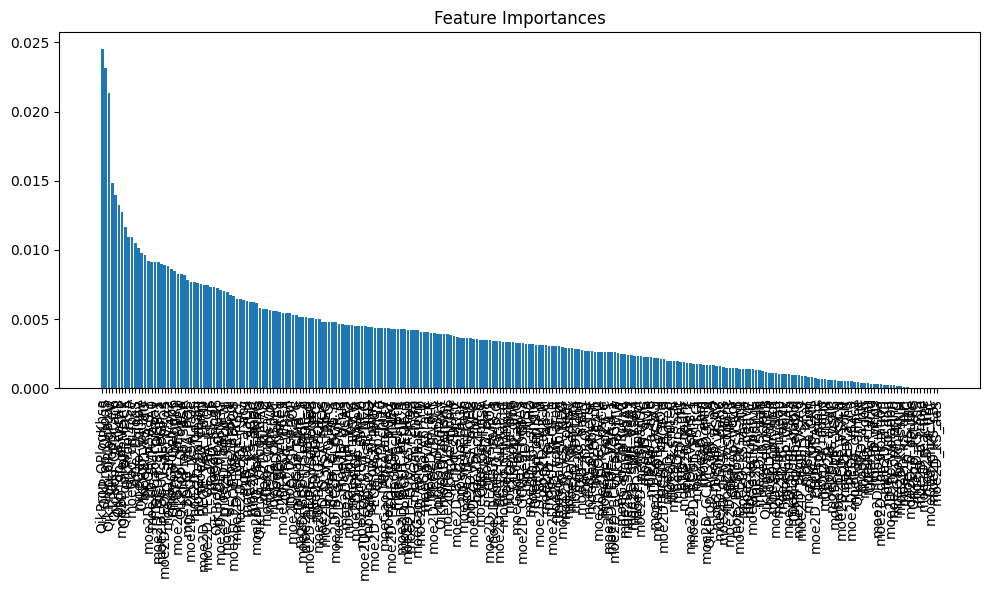

In [11]:
# analyse model performance: performance metrics and feature importance
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test, y_test_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_best))
import matplotlib.pyplot as plt
import numpy as np
feature_importances = best_model.feature_importances_
features = X.columns
indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()  

The Model is better at identifying inactive compounds (Precision 0.82) than at identifying active compounds (Precision 0.57) which could be used as drugs.
The graph shows that the first 3-4 features are the most influential. 

Cohen Kappa Score: 0.2883435582822086


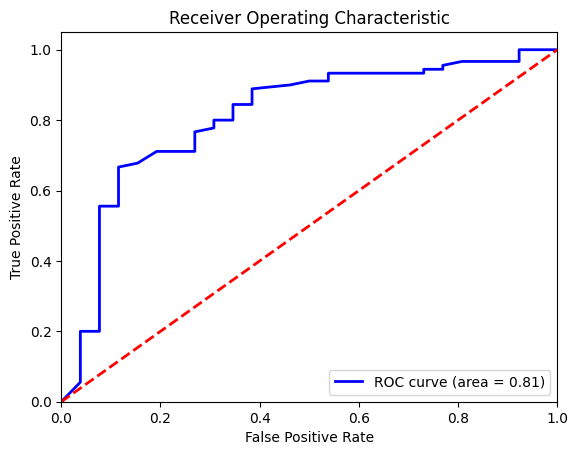

In [16]:
# evaluate the model using the cohen kappa score and roc curve
from sklearn.metrics import cohen_kappa_score, roc_curve, auc
kappa_score = cohen_kappa_score(y_test, y_test_pred_best)
print("Cohen Kappa Score:", kappa_score)
y_test_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob, pos_label="Inactive")
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()  

the model (blue line ) is better than random guess (red line)
the accuracy is high, but the kappa score, which accounts for class imbalance, is only 0.288, so the accuracy is probably high because there are more inactive than active compounds in the dataset 

In [17]:
print(y.value_counts())

cox2Class
Inactive    372
Active       90
Name: count, dtype: int64


In [18]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_best, labels=["Inactive", "Active"]).ravel()

sensitivity = tp / (tp + fn)  # recall for Active
specificity = tn / (tn + fp)  # recall for Inactive

print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

Sensitivity (True Positive Rate): 0.3077
Specificity (True Negative Rate): 0.9333
